In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import os


In [20]:
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
if os.path.exists(font_path):
    font_name = fm.FontProperties(fname=font_path).get_name()
    plt.rc('font', family=font_name)
else:
    plt.rc('font', family='DejaVu Sans')

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

In [21]:
recent_path = "../data/aladin_books_recent.csv"
best_path = "../data/aladin_books_bestseller.csv"

In [22]:
df_recent = pd.read_csv(recent_path)
df_best = pd.read_csv(best_path)

In [23]:
df_recent['source'] = 'Recent'
df_best['source'] = 'Bestseller'

### 텍스트 길이 분석

In [24]:
for df in [df_recent, df_best]:
    df['desc_len'] = df['description'].fillna('').str.len()
    df['title_len'] = df['title'].str.len()

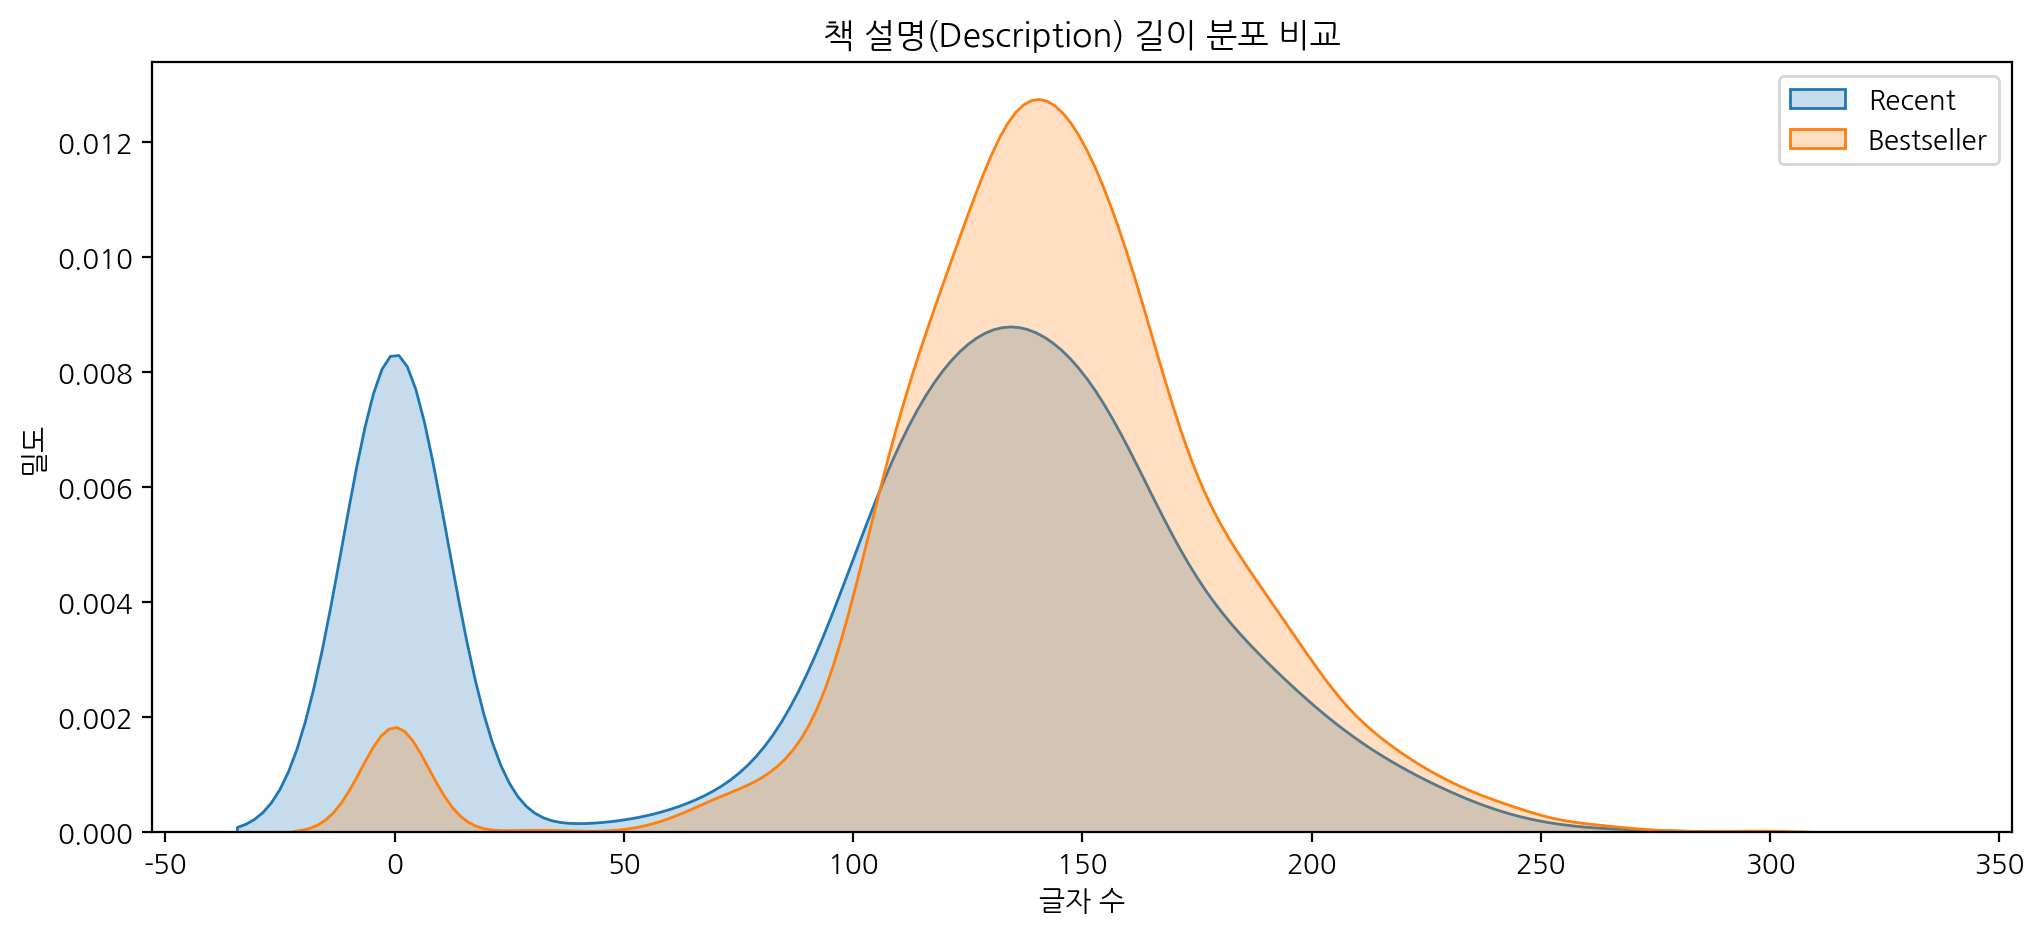

In [25]:
plt.figure(figsize=(12, 5))
sns.kdeplot(data=df_recent, x='desc_len', label='Recent', fill=True)
sns.kdeplot(data=df_best, x='desc_len', label='Bestseller', fill=True)
plt.title("책 설명(Description) 길이 분포 비교")
plt.xlabel("글자 수")
plt.ylabel("밀도")
plt.legend()
plt.show()

### 평점

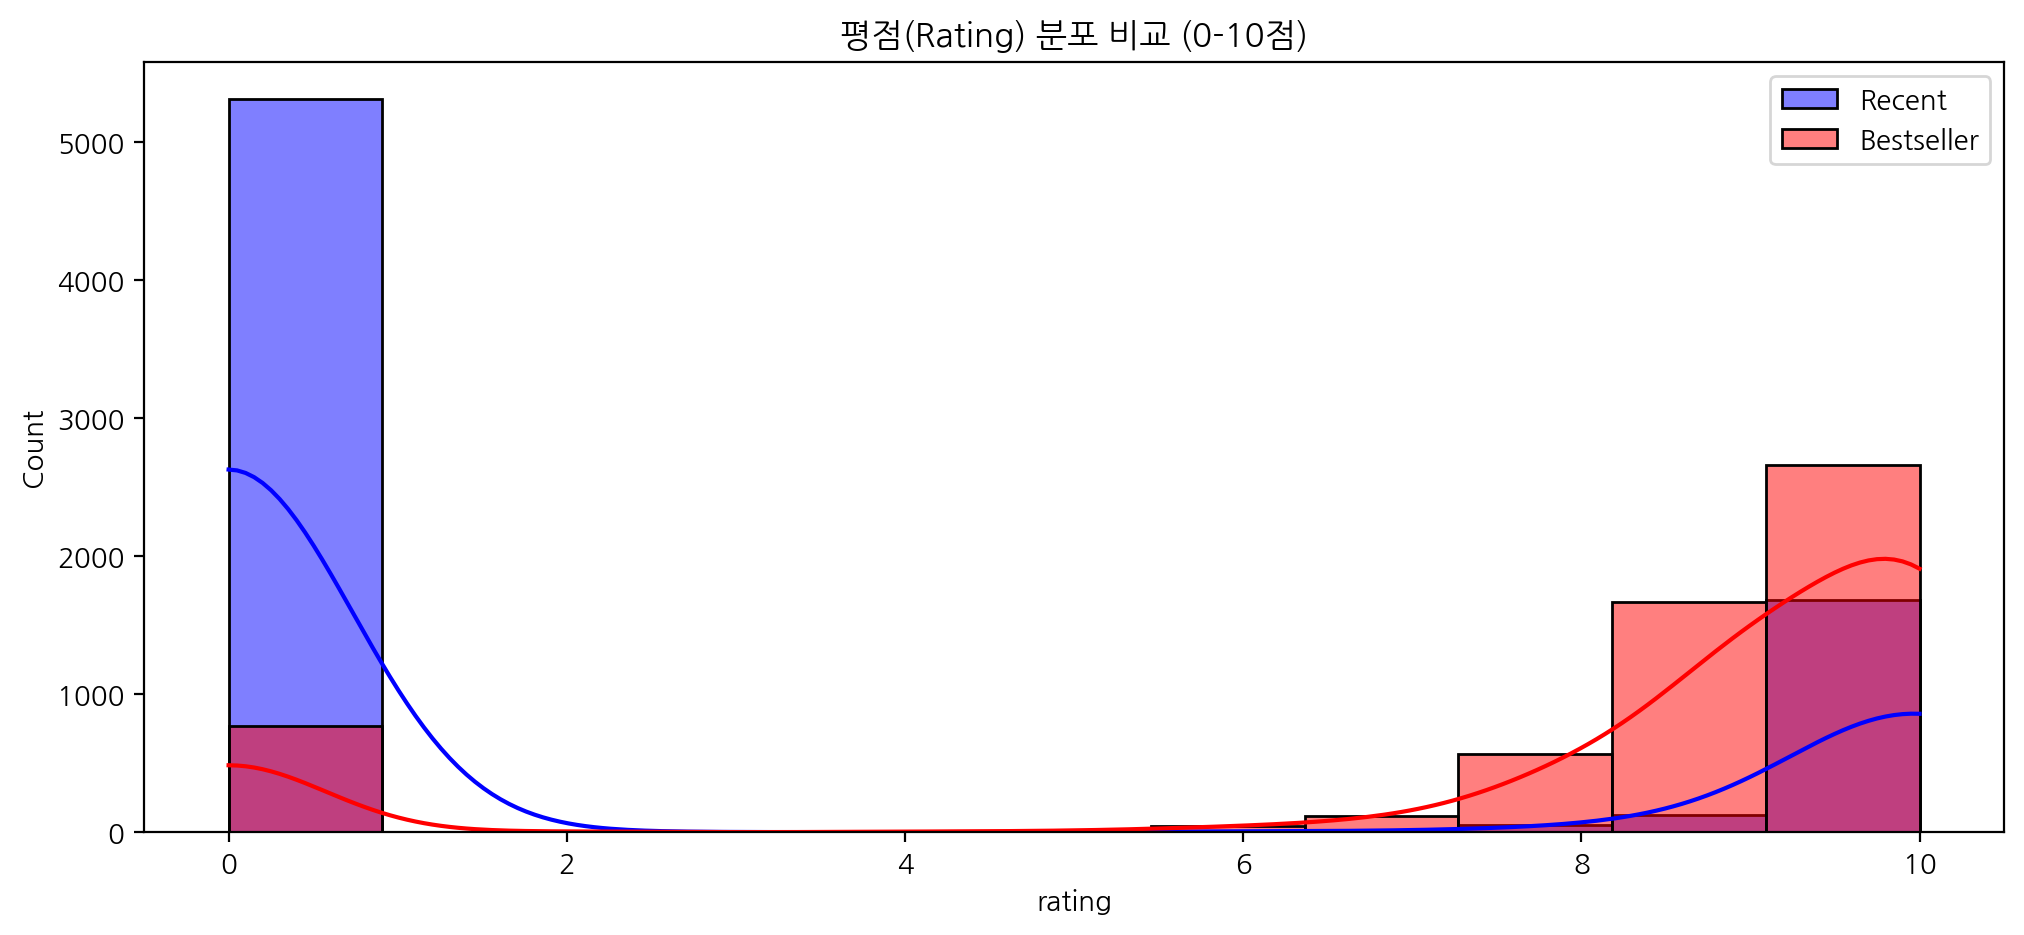

In [26]:
plt.figure(figsize=(12, 5))
# 0점(평가없음)을 제외하고 분석하거나 포함해서 비교
sns.histplot(data=df_recent, x='rating', bins=11, label='Recent', kde=True, color='blue', alpha=0.5)
sns.histplot(data=df_best, x='rating', bins=11, label='Bestseller', kde=True, color='red', alpha=0.5)
plt.title("평점(Rating) 분포 비교 (0-10점)")
plt.legend()
plt.show()

### 주요 통계치 비교

In [27]:
stats = []
for df, name in [(df_recent, "Recent"), (df_best, "Bestseller")]:
    stats.append({
        "Dataset": name,
        "Total Count": len(df),
        "Desc Mean Len": df['desc_len'].mean(),
        "Desc Median Len": df['desc_len'].median(),
        "Rating Mean": df[df['rating'] > 0]['rating'].mean(), # 0점 제외 평균
        "Rating Median": df[df['rating'] > 0]['rating'].median(),
        "Missing Desc %": (df['description'].isna().sum() / len(df)) * 100
    })

df_stats = pd.DataFrame(stats)
display(df_stats)

,Dataset,Total Count,Desc Mean Len,Desc Median Len,Rating Mean,Rating Median,Missing Desc %
0,Recent,7212,108.045341,126.0,9.790943,10.0,23.863006
1,Bestseller,5870,142.068995,143.0,9.306651,10.0,3.390119
